In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# run in Colab
from google.colab import files
import io, pandas as pd

uploaded = files.upload()           # select your file
fn = list(uploaded.keys())[0]
print("Uploaded file:", fn)

# Try to load as CSV; if Excel, change to read_excel
try:
    df = pd.read_csv(io.BytesIO(uploaded[fn]), low_memory=False)
except Exception as e:
    print("read_csv error:", type(e).__name__, e)
    # fallback attempts
    df = pd.read_csv(io.BytesIO(uploaded[fn]), encoding='latin1', low_memory=False)
print("Loaded shape:", df.shape)


Saving crt_solar_data_copy.csv to crt_solar_data_copy.csv
Uploaded file: crt_solar_data_copy.csv
Loaded shape: (107328, 31)


In [3]:
df["dt"] = pd.to_datetime(df["date"] + " " + df["time"], format="%d-%m-%Y %H:%M:%S")


In [4]:
# 2. Create total_power = sum of all 3 plant outputs
df["total_power"] = (
    df["SOLAR 120.990kw-I/P"]
    + df["SOLAR 68.88KW"]
    + df["57.810KW -Solar"]
)

In [5]:
# 3. Check basic stats
print(df[["SOLAR 120.990kw-I/P", "SOLAR 68.88KW", "57.810KW -Solar", "total_power"]].head())

print("\nMin & Max of total_power:")
print("min:", df["total_power"].min())
print("max:", df["total_power"].max())

   SOLAR 120.990kw-I/P  SOLAR 68.88KW  57.810KW -Solar  total_power
0                  0.0            0.0              0.0          0.0
1                  0.0            0.0              0.0          0.0
2                  0.0            0.0              0.0          0.0
3                  0.0            0.0              0.0          0.0
4                  0.0            0.0              0.0          0.0

Min & Max of total_power:
min: 0.0
max: 903013.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107328 entries, 0 to 107327
Data columns (total 33 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   date                 107328 non-null  object        
 1   time                 107328 non-null  object        
 2   air_temp             107328 non-null  int64         
 3   clearsky_dhi         107328 non-null  int64         
 4   clearsky_dni         107328 non-null  int64         
 5   clearsky_ghi         107328 non-null  int64         
 6   clearsky_gti         107328 non-null  int64         
 7   cloud_opacity        107328 non-null  float64       
 8   dewpoint_temp        107328 non-null  float64       
 9   dhi                  107328 non-null  int64         
 10  dni                  107328 non-null  int64         
 11  ghi                  107328 non-null  int64         
 12  gti                  107328 non-null  int64         
 13  precipitable_w

## understanding y

In [7]:
print("SOLAR 120.990kw-I/P :")
print("min:", df["SOLAR 120.990kw-I/P"].min())
print("max:", df["SOLAR 120.990kw-I/P"].max())

print("SOLAR 68.88KW :")
print("min:", df["SOLAR 68.88KW"].min())
print("max:", df["SOLAR 68.88KW"].max())

print("57.810KW -Solar :")
print("min:", df["57.810KW -Solar"].min())
print("max:", df["57.810KW -Solar"].max())

print("\nMin & Max of total_power:")
print("min:", df["total_power"].min())
print("max:", df["total_power"].max())

SOLAR 120.990kw-I/P :
min: 0.0
max: 556942.78
SOLAR 68.88KW :
min: 0.0
max: 157033.5
57.810KW -Solar :
min: 0.0
max: 189036.72

Min & Max of total_power:
min: 0.0
max: 903013.0


In [8]:
df[df["total_power"] > 300].head(10)
#print(df[df["total_power"] > 300]["total_power"].describe())

,date,time,air_temp,clearsky_dhi,clearsky_dni,clearsky_ghi,clearsky_gti,cloud_opacity,dewpoint_temp,dhi,...,albedo,azimuth,zenith,min_air_temp,max_air_temp,SOLAR 120.990kw-I/P,SOLAR 68.88KW,57.810KW -Solar,dt,total_power
21474,28-02-2023,16:45:00,31,171,299,301,320,78.5,19.2,65,...,0.17,105,64,21.9,32.3,106456.79,0.00,0.00,2023-02-28 16:45:00,106456.79
35763,27-07-2023,13:00:00,34,192,735,914,801,2.2,20.0,224,...,0.17,37,11,26.1,35.5,191275.12,0.00,0.00,2023-07-27 13:00:00,191275.12
40376,13-09-2023,14:15:00,37,151,766,821,795,41.9,20.9,471,...,0.16,101,29,27.5,37.3,6.99,0.00,10176.81,2023-09-13 14:15:00,10183.80
41844,28-09-2023,21:15:00,28,0,0,0,0,94.9,21.2,0,...,0.16,81,134,25.8,35.6,300.70,0.00,0.01,2023-09-28 21:15:00,300.71
46504,16-11-2023,10:15:00,27,243,566,671,756,27.3,22.8,444,...,0.17,-136,41,24.0,30.9,249969.79,0.00,24068.52,2023-11-16 10:15:00,274038.31
46520,16-11-2023,14:15:00,31,215,610,665,755,19.5,22.0,376,...,0.17,133,43,24.0,30.9,250217.81,0.00,24179.24,2023-11-16 14:15:00,274397.05
47561,27-11-2023,10:30:00,27,112,839,748,880,8.0,23.0,207,...,0.16,-141,41,23.9,30.8,503.70,0.00,7.45,2023-11-27 10:30:00,511.15
55816,21-02-2024,10:15:00,28,254,566,674,726,0.0,21.3,254,...,0.17,-121,42,25.1,36.7,17.60,10.37,323.64,2024-02-21 10:15:00,351.61
72067,08-08-2024,17:00:00,30,115,480,316,250,48.9,22.9,161,...,0.17,77,65,25.6,32.4,343.90,181.18,196.01,2024-08-08 17:00:00,721.09
74446,02-09-2024,11:45:00,35,146,805,938,889,5.7,22.1,232,...,0.16,-106,10,26.2,36.8,272.70,0.00,143.50,2024-09-02 11:45:00,416.20


In [9]:
MAX_CAPACITY = 260

df_clean = df[df["total_power"] <= MAX_CAPACITY].copy()

print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Removed rows:", len(df) - len(df_clean))

print("New max:", df_clean["total_power"].max())


Original rows: 107328
Cleaned rows: 107312
Removed rows: 16
New max: 216.62


In [10]:
print("SOLAR 120.990kw-I/P :")
print("min:", df_clean["SOLAR 120.990kw-I/P"].min())
print("max:", df_clean["SOLAR 120.990kw-I/P"].max())

print("SOLAR 68.88KW :")
print("min:", df_clean["SOLAR 68.88KW"].min())
print("max:", df_clean["SOLAR 68.88KW"].max())

print("57.810KW -Solar :")
print("min:", df_clean["57.810KW -Solar"].min())
print("max:", df_clean["57.810KW -Solar"].max())

print("\nMin & Max of total_power:")
print("min:", df_clean["total_power"].min())
print("max:", df_clean["total_power"].max())

SOLAR 120.990kw-I/P :
min: 0.0
max: 147.9
SOLAR 68.88KW :
min: 0.0
max: 92.9
57.810KW -Solar :
min: 0.0
max: 197.7

Min & Max of total_power:
min: 0.0
max: 216.62


In [11]:
df_clean2 = df_clean[
    (df_clean["SOLAR 120.990kw-I/P"] <= 135) &
    (df_clean["SOLAR 68.88KW"] <= 80) &
    (df_clean["57.810KW -Solar"] <= 70)
].copy()

print("Rows after individual inverter cleaning:", len(df_clean2))
print("Removed rows:", len(df_clean) - len(df_clean2))

print("New max per inverter:")
print(df_clean2["SOLAR 120.990kw-I/P"].max(),
      df_clean2["SOLAR 68.88KW"].max(),
      df_clean2["57.810KW -Solar"].max())


Rows after individual inverter cleaning: 107309
Removed rows: 3
New max per inverter:
124.7 57.79 64.22


In [12]:
df_day = df_clean2[df_clean2["ghi"] > 50].copy()

print("Daytime rows:", len(df_day))
print("Night rows removed:", len(df_clean2) - len(df_day))

print(df_day[["total_power", "ghi"]].head())


Daytime rows: 48385
Night rows removed: 58924
    total_power  ghi
28         6.82   65
29         6.98   98
30         7.01  143
31         6.82  197
32         0.00  239


In [13]:
corr = df_day.corr(numeric_only=True)

corr_with_target = corr["total_power"].sort_values(ascending=False)

print(corr_with_target)


total_power            1.000000
SOLAR 120.990kw-I/P    0.870144
57.810KW -Solar        0.864392
SOLAR 68.88KW          0.827520
ghi                    0.665768
gti                    0.651635
clearsky_ghi           0.598987
clearsky_gti           0.570850
clearsky_dni           0.503322
dni                    0.496304
clearsky_dhi           0.407248
dhi                    0.301644
air_temp               0.206714
max_air_temp           0.184661
surface_pressure       0.119151
min_air_temp           0.095714
albedo                 0.056772
wind_speed_10m         0.038656
wind_direction_100m   -0.015956
wind_direction_10m    -0.020746
wind_speed_100m       -0.024268
dewpoint_temp         -0.024562
precipitation_rate    -0.094227
precipitable_water    -0.101387
azimuth               -0.123800
relative_humidity     -0.184685
cloud_opacity         -0.327790
zenith                -0.583023
Name: total_power, dtype: float64


In [14]:
n = len(df_day)
train_size = int(n * 0.8)

train = df_day.iloc[:train_size]
test = df_day.iloc[train_size:]

print("Train rows:", len(train))
print("Test rows:", len(test))

print("Train datetime range:", train["dt"].min(), "to", train["dt"].max())
print("Test datetime range:", test["dt"].min(), "to", test["dt"].max())


Train rows: 38708
Test rows: 9677
Train datetime range: 2022-07-20 07:15:00 to 2025-01-04 09:45:00
Test datetime range: 2025-01-04 10:00:00 to 2025-08-10 17:30:00


In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

features = [
    "ghi", "gti", "dni",
    "clearsky_ghi", "clearsky_gti", "clearsky_dni",
    "cloud_opacity", "zenith",
    "air_temp", "relative_humidity", "precipitable_water"
]

X_train = train[features]
y_train = train["total_power"]

X_test = test[features]
y_test = test["total_power"]

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mape = np.mean(np.abs((y_test - y_pred) / np.clip(y_test, 1e-3, None))) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)


MAE: 9.872005637077606
RMSE: 12.677769484789765
MAPE: 145764.06323101872


In [16]:
mask = y_test > 20  # consider only significant production time
mae_day = mean_absolute_error(y_test[mask], y_pred[mask])
rmse_day = (mean_squared_error(y_test[mask], y_pred[mask])) ** 0.5
mape_day = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

print("Daytime MAE:", mae_day)
print("Daytime RMSE:", rmse_day)
print("Daytime MAPE:", mape_day)
print("Samples used:", mask.sum())


Daytime MAE: 13.053254175286815
Daytime RMSE: 14.931822763313399
Daytime MAPE: 36.85683050901732
Samples used: 5317


In [17]:
df_day["hour"] = df_day["dt"].dt.hour + df_day["dt"].dt.minute/60
df_day["dayofyear"] = df_day["dt"].dt.dayofyear
df_day["month"] = df_day["dt"].dt.month
df_day["weekday"] = df_day["dt"].dt.weekday

In [18]:
# Recreate train-test split AFTER adding time features
n = len(df_day)
train_size = int(n * 0.8)

train = df_day.iloc[:train_size]
test = df_day.iloc[train_size:]

print("Train columns check:")
print(train.columns)

print("\nTest columns check:")
print(test.columns)


Train columns check:
Index(['date', 'time', 'air_temp', 'clearsky_dhi', 'clearsky_dni',
       'clearsky_ghi', 'clearsky_gti', 'cloud_opacity', 'dewpoint_temp', 'dhi',
       'dni', 'ghi', 'gti', 'precipitable_water', 'precipitation_rate',
       'relative_humidity', 'surface_pressure', 'wind_direction_100m',
       'wind_direction_10m', 'wind_speed_100m', 'wind_speed_10m',
       'weather_type', 'period', 'albedo', 'azimuth', 'zenith', 'min_air_temp',
       'max_air_temp', 'SOLAR 120.990kw-I/P', 'SOLAR 68.88KW',
       '57.810KW -Solar', 'dt', 'total_power', 'hour', 'dayofyear', 'month',
       'weekday'],
      dtype='object')

Test columns check:
Index(['date', 'time', 'air_temp', 'clearsky_dhi', 'clearsky_dni',
       'clearsky_ghi', 'clearsky_gti', 'cloud_opacity', 'dewpoint_temp', 'dhi',
       'dni', 'ghi', 'gti', 'precipitable_water', 'precipitation_rate',
       'relative_humidity', 'surface_pressure', 'wind_direction_100m',
       'wind_direction_10m', 'wind_speed_100m', 'wi

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

features = [
    "ghi", "gti", "dni",
    "clearsky_ghi", "clearsky_gti", "clearsky_dni",
    "cloud_opacity", "zenith",
    "air_temp", "relative_humidity", "precipitable_water",
    "hour", "dayofyear", "month", "weekday"
]

X_train = train[features]
y_train = train["total_power"]

X_test = test[features]
y_test = test["total_power"]

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Overall metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

# Daytime-focused metrics
mask = y_test > 20
mae_day = mean_absolute_error(y_test[mask], y_pred[mask])
rmse_day = mean_squared_error(y_test[mask], y_pred[mask]) ** 0.5
mape_day = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

print("Overall MAE:", mae)
print("Overall RMSE:", rmse)
print("Daytime MAE:", mae_day)
print("Daytime RMSE:", rmse_day)
print("Daytime MAPE:", mape_day)
print("Samples used:", mask.sum())


Overall MAE: 9.525343908236023
Overall RMSE: 12.531932098584134
Daytime MAE: 12.304127092345308
Daytime RMSE: 14.384731083430804
Daytime MAPE: 34.898760291457705
Samples used: 5317


In [20]:
df_day["power_lag_1"] = df_day["total_power"].shift(1)

In [21]:
df_day = df_day.dropna().reset_index(drop=True)

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Recreate train-test split AFTER lag feature
n = len(df_day)
train_size = int(n * 0.8)

train = df_day.iloc[:train_size]
test = df_day.iloc[train_size:]

features = [
    "ghi", "gti", "dni",
    "clearsky_ghi", "clearsky_gti", "clearsky_dni",
    "cloud_opacity", "zenith",
    "air_temp", "relative_humidity", "precipitable_water",
    "hour", "dayofyear", "month", "weekday",
    "power_lag_1"          # 🔥 lag feature
]

X_train = train[features]
y_train = train["total_power"]

X_test = test[features]
y_test = test["total_power"]

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Overall metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

# Daytime metrics
mask = y_test > 20
mae_day = mean_absolute_error(y_test[mask], y_pred[mask])
rmse_day = mean_squared_error(y_test[mask], y_pred[mask]) ** 0.5
mape_day = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

print("Overall MAE:", mae)
print("Overall RMSE:", rmse)
print("Daytime MAE:", mae_day)
print("Daytime RMSE:", rmse_day)
print("Daytime MAPE:", mape_day)
print("Samples used:", mask.sum())


Overall MAE: 3.3428773535186522
Overall RMSE: 5.491445927898454
Daytime MAE: 4.331102792928343
Daytime RMSE: 6.379292166946672
Daytime MAPE: 13.104854000899389
Samples used: 5317


In [23]:
df_day.head()

,date,time,air_temp,clearsky_dhi,clearsky_dni,clearsky_ghi,clearsky_gti,cloud_opacity,dewpoint_temp,dhi,...,SOLAR 120.990kw-I/P,SOLAR 68.88KW,57.810KW -Solar,dt,total_power,hour,dayofyear,month,weekday,power_lag_1
0,20-07-2022,07:30:00,27,92,359,200,136,51.3,23.5,98,...,0.0,6.98,0.0,2022-07-20 07:30:00,6.98,7.50,201,7,2,6.82
1,20-07-2022,07:45:00,27,106,415,254,180,43.6,23.5,143,...,0.0,7.01,0.0,2022-07-20 07:45:00,7.01,7.75,201,7,2,6.98
2,20-07-2022,08:00:00,27,118,462,309,228,36.3,23.5,197,...,0.0,6.82,0.0,2022-07-20 08:00:00,6.82,8.00,201,7,2,7.01
3,20-07-2022,08:15:00,27,130,496,363,276,34.2,23.6,236,...,0.0,0.00,0.0,2022-07-20 08:15:00,0.00,8.25,201,7,2,6.82
4,20-07-2022,08:30:00,28,144,520,415,324,35.4,23.6,268,...,0.0,0.00,0.0,2022-07-20 08:30:00,0.00,8.50,201,7,2,0.00


In [24]:
df_day["power_lag_2"] = df_day["total_power"].shift(2)


In [25]:
df_day = df_day.dropna().reset_index(drop=True)

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Recreate train-test split AFTER adding second lag
n = len(df_day)
train_size = int(n * 0.8)

train = df_day.iloc[:train_size]
test = df_day.iloc[train_size:]

features = [
    "ghi", "gti", "dni",
    "clearsky_ghi", "clearsky_gti", "clearsky_dni",
    "cloud_opacity", "zenith",
    "air_temp", "relative_humidity", "precipitable_water",
    "hour", "dayofyear", "month", "weekday",
    "power_lag_1",
    "power_lag_2"   # 🔥 second lag
]

X_train = train[features]
y_train = train["total_power"]

X_test = test[features]
y_test = test["total_power"]

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Overall metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

# Daytime-focused metrics
mask = y_test > 20
mae_day = mean_absolute_error(y_test[mask], y_pred[mask])
rmse_day = mean_squared_error(y_test[mask], y_pred[mask]) ** 0.5
mape_day = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

print("Overall MAE:", mae)
print("Overall RMSE:", rmse)
print("Daytime MAE:", mae_day)
print("Daytime RMSE:", rmse_day)
print("Daytime MAPE:", mape_day)
print("Samples used:", mask.sum())


Overall MAE: 3.263664307119975
Overall RMSE: 5.3654741263179675
Daytime MAE: 4.19750086514952
Daytime RMSE: 6.148031603368088
Daytime MAPE: 12.714912162473347
Samples used: 5317


In [27]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Use same train-test split and same features
features = [
    "ghi", "gti", "dni",
    "clearsky_ghi", "clearsky_gti", "clearsky_dni",
    "cloud_opacity", "zenith",
    "air_temp", "relative_humidity", "precipitable_water",
    "hour", "dayofyear", "month", "weekday",
    "power_lag_1", "power_lag_2"
]

X_train = train[features]
y_train = train["total_power"]

X_test = test[features]
y_test = test["total_power"]

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

mask = y_test > 20
mae_day = mean_absolute_error(y_test[mask], y_pred[mask])
rmse_day = mean_squared_error(y_test[mask], y_pred[mask]) ** 0.5
mape_day = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

print("Overall MAE:", mae)
print("Overall RMSE:", rmse)
print("Daytime MAE:", mae_day)
print("Daytime RMSE:", rmse_day)
print("Daytime MAPE:", mape_day)
print("Samples used:", mask.sum())


Overall MAE: 3.2477794613956177
Overall RMSE: 5.368808473527965
Daytime MAE: 4.206166345057323
Daytime RMSE: 6.270343229003599
Daytime MAPE: 12.747360812754934
Samples used: 5317


In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Recreate train-test split AFTER adding second lag
n = len(df_day)
train_size = int(n * 0.8)

train = df_day.iloc[:train_size]
test = df_day.iloc[train_size:]

features = [
    "ghi", "gti", "dni",
    "clearsky_ghi", "clearsky_gti", "clearsky_dni",
    "cloud_opacity", "zenith",
    "air_temp", "relative_humidity", "precipitable_water",
    "hour", "dayofyear", "month", "weekday",
    "power_lag_1",
    "power_lag_2"   # 🔥 second lag
]

X_train = train[features]
y_train = train["total_power"]

X_test = test[features]
y_test = test["total_power"]

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Overall metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

# Daytime-focused metrics
mask = y_test > 20
mae_day = mean_absolute_error(y_test[mask], y_pred[mask])
rmse_day = mean_squared_error(y_test[mask], y_pred[mask]) ** 0.5
mape_day = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100

print("Overall MAE:", mae)
print("Overall RMSE:", rmse)
print("Daytime MAE:", mae_day)
print("Daytime RMSE:", rmse_day)
print("Daytime MAPE:", mape_day)
print("Samples used:", mask.sum())


Overall MAE: 3.263664307119975
Overall RMSE: 5.3654741263179675
Daytime MAE: 4.19750086514952
Daytime RMSE: 6.148031603368088
Daytime MAPE: 12.714912162473347
Samples used: 5317


In [29]:
test = test.copy()  # make it explicit

test.loc[:, "abs_error"] = np.abs(y_test - y_pred)
test.loc[:, "perc_error"] = (
    np.abs(y_test - y_pred) / np.clip(y_test, 1e-3, None) * 100
)


In [30]:
ghi_bins = [0, 100, 300, 600, 1000]
test["ghi_bin"] = pd.cut(test["ghi"], bins=ghi_bins)

In [31]:
ghi_error_summary = test.groupby("ghi_bin")[["abs_error", "perc_error"]].mean()
print(ghi_error_summary)


             abs_error    perc_error
ghi_bin                             
(0, 100]      0.843585  11796.498203
(100, 300]    1.675305   8454.403039
(300, 600]    3.331731  14077.714847
(600, 1000]   4.460885  15348.086023


/tmp/ipython-input-740440599.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ghi_error_summary = test.groupby("ghi_bin")[["abs_error", "perc_error"]].mean()


In [32]:
# Bin cloud opacity
cloud_bins = [0, 20, 40, 60, 80, 100]
test["cloud_bin"] = pd.cut(test["cloud_opacity"], bins=cloud_bins)

cloud_error_summary = test.groupby("cloud_bin")[["abs_error"]].mean()
print(cloud_error_summary)


           abs_error
cloud_bin           
(0, 20]     4.037282
(20, 40]    3.668012
(40, 60]    2.856375
(60, 80]    3.260656
(80, 100]   3.428729


/tmp/ipython-input-3338059392.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cloud_error_summary = test.groupby("cloud_bin")[["abs_error"]].mean()


In [33]:
# Create hour bins
hour_bins = [6, 9, 12, 15, 18]
test["hour_bin"] = pd.cut(test["hour"], bins=hour_bins)

hour_error_summary = test.groupby("hour_bin")[["abs_error"]].mean()
print(hour_error_summary)


          abs_error
hour_bin           
(6, 9]     1.744700
(9, 12]    4.408706
(12, 15]   4.666796
(15, 18]   1.767348


/tmp/ipython-input-2836863582.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hour_error_summary = test.groupby("hour_bin")[["abs_error"]].mean()


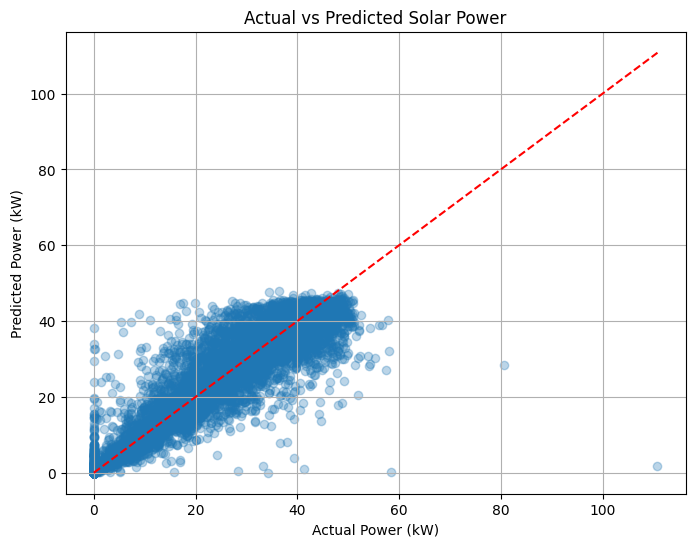

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--')
plt.xlabel("Actual Power (kW)")
plt.ylabel("Predicted Power (kW)")
plt.title("Actual vs Predicted Solar Power")
plt.grid(True)
plt.show()


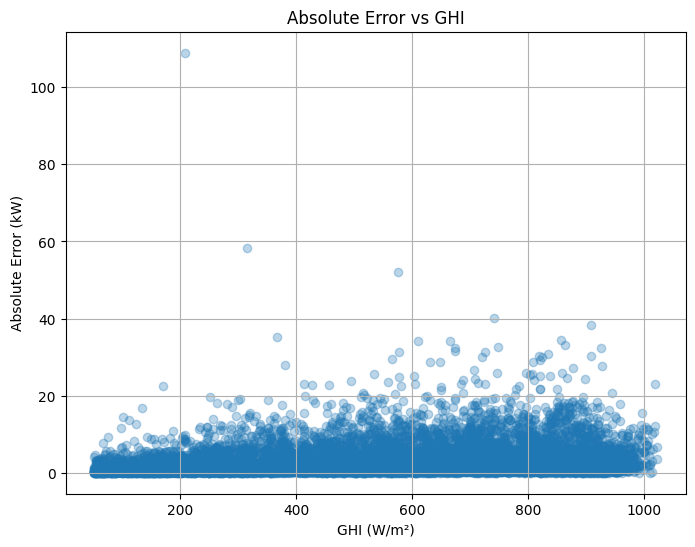

In [35]:
plt.figure(figsize=(8, 6))
plt.scatter(test["ghi"], test["abs_error"], alpha=0.3)
plt.xlabel("GHI (W/m²)")
plt.ylabel("Absolute Error (kW)")
plt.title("Absolute Error vs GHI")
plt.grid(True)
plt.show()


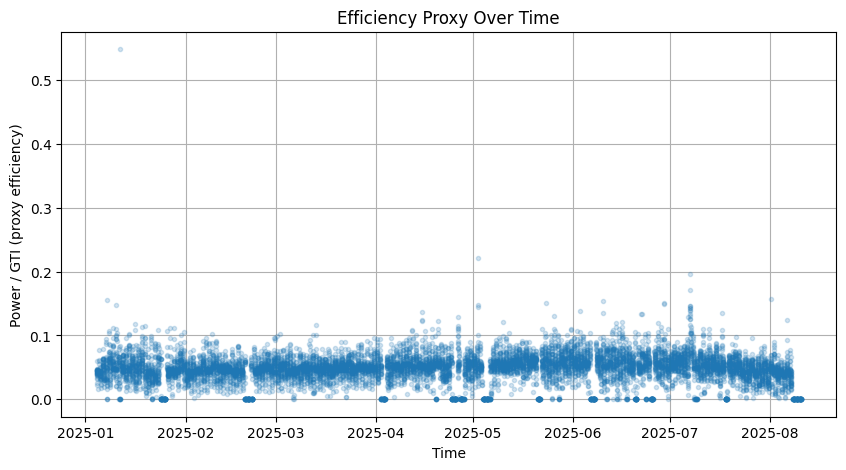

In [36]:
test["efficiency_proxy"] = test["total_power"] / np.clip(test["gti"], 1e-3, None)

plt.figure(figsize=(10, 5))
plt.plot(test["dt"], test["efficiency_proxy"], '.', alpha=0.2)
plt.xlabel("Time")
plt.ylabel("Power / GTI (proxy efficiency)")
plt.title("Efficiency Proxy Over Time")
plt.grid(True)
plt.show()


## Model finalization

In [37]:
features = [
    "ghi", "gti", "dni",
    "clearsky_ghi", "clearsky_gti", "clearsky_dni",
    "cloud_opacity", "zenith",
    "air_temp", "relative_humidity", "precipitable_water",
    "hour", "dayofyear", "month", "weekday",
    "power_lag_1", "power_lag_2"
]


In [38]:
from sklearn.ensemble import RandomForestRegressor

# Final feature list (LOCKED)
features = [
    "ghi", "gti", "dni",
    "clearsky_ghi", "clearsky_gti", "clearsky_dni",
    "cloud_opacity", "zenith",
    "air_temp", "relative_humidity", "precipitable_water",
    "hour", "dayofyear", "month", "weekday",
    "power_lag_1", "power_lag_2"
]

X_full = df_day[features]
y_full = df_day["total_power"]

final_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_full, y_full)

print("Final model trained on full dataset")
print("Total samples used:", len(X_full))


Final model trained on full dataset
Total samples used: 48382


In [39]:
import joblib

joblib.dump(final_model, "solar_power_rf_v1.joblib")
print("Model saved as solar_power_rf_v1.joblib")


Model saved as solar_power_rf_v1.joblib


In [40]:
import pandas as pd
import numpy as np
import joblib

FEATURES = [
    "ghi", "gti", "dni",
    "clearsky_ghi", "clearsky_gti", "clearsky_dni",
    "cloud_opacity", "zenith",
    "air_temp", "relative_humidity", "precipitable_water",
    "hour", "dayofyear", "month", "weekday",
    "power_lag_1", "power_lag_2"
]

def predict_solar_power(
    model,
    dt,                      # pandas.Timestamp
    weather_inputs,          # dict with weather keys below
    power_lag_1,             # last timestep power (kW)
    power_lag_2              # power from two steps ago (kW)
):
    """
    weather_inputs keys required:
    ghi, gti, dni,
    clearsky_ghi, clearsky_gti, clearsky_dni,
    cloud_opacity, zenith,
    air_temp, relative_humidity, precipitable_water
    """

    row = {
        "ghi": weather_inputs["ghi"],
        "gti": weather_inputs["gti"],
        "dni": weather_inputs["dni"],
        "clearsky_ghi": weather_inputs["clearsky_ghi"],
        "clearsky_gti": weather_inputs["clearsky_gti"],
        "clearsky_dni": weather_inputs["clearsky_dni"],
        "cloud_opacity": weather_inputs["cloud_opacity"],
        "zenith": weather_inputs["zenith"],
        "air_temp": weather_inputs["air_temp"],
        "relative_humidity": weather_inputs["relative_humidity"],
        "precipitable_water": weather_inputs["precipitable_water"],
        "hour": dt.hour + dt.minute / 60.0,
        "dayofyear": dt.dayofyear,
        "month": dt.month,
        "weekday": dt.weekday(),
        "power_lag_1": power_lag_1,
        "power_lag_2": power_lag_2
    }

    X = pd.DataFrame([row], columns=FEATURES)
    prediction = model.predict(X)[0]
    return float(prediction)


In [41]:
loaded_model = joblib.load("solar_power_rf_v1.joblib")

example_weather = {
    "ghi": 650,
    "gti": 720,
    "dni": 780,
    "clearsky_ghi": 700,
    "clearsky_gti": 760,
    "clearsky_dni": 820,
    "cloud_opacity": 20,
    "zenith": 30,
    "air_temp": 34,
    "relative_humidity": 55,
    "precipitable_water": 30
}

dt_now = pd.Timestamp("2025-08-15 12:15:00")

pred = predict_solar_power(
    model=loaded_model,
    dt=dt_now,
    weather_inputs=example_weather,
    power_lag_1=120.5,
    power_lag_2=118.9
)

print("Predicted power (kW):", pred)


Predicted power (kW): 13.196300000000003


## Testing train test split


In [42]:
# Total samples
n = len(df_day)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df_day.iloc[:train_end]
val_df   = df_day.iloc[train_end:val_end]
test_df  = df_day.iloc[val_end:]

print("Train samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

print("\nDate ranges:")
print("Train:", train_df["dt"].min(), "→", train_df["dt"].max())
print("Validation:", val_df["dt"].min(), "→", val_df["dt"].max())
print("Test:", test_df["dt"].min(), "→", test_df["dt"].max())


Train samples: 33867
Validation samples: 7257
Test samples: 7258

Date ranges:
Train: 2022-07-20 08:00:00 → 2024-09-10 10:30:00
Validation: 2024-09-10 10:45:00 → 2025-03-02 13:30:00
Test: 2025-03-02 13:45:00 → 2025-08-10 17:30:00


In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

features = [
    "ghi", "gti", "dni",
    "clearsky_ghi", "clearsky_gti", "clearsky_dni",
    "cloud_opacity", "zenith",
    "air_temp", "relative_humidity", "precipitable_water",
    "hour", "dayofyear", "month", "weekday",
    "power_lag_1", "power_lag_2"
]

# Train set
X_train = train_df[features]
y_train = train_df["total_power"]

# Validation set
X_val = val_df[features]
y_val = val_df["total_power"]

model_tv = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_tv.fit(X_train, y_train)
y_val_pred = model_tv.predict(X_val)

# Metrics
mae_val = mean_absolute_error(y_val, y_val_pred)
rmse_val = mean_squared_error(y_val, y_val_pred) ** 0.5

mask = y_val > 20
mae_day = mean_absolute_error(y_val[mask], y_val_pred[mask])
rmse_day = mean_squared_error(y_val[mask], y_val_pred[mask]) ** 0.5
mape_day = np.mean(np.abs((y_val[mask] - y_val_pred[mask]) / y_val[mask])) * 100

print("Validation MAE:", mae_val)
print("Validation RMSE:", rmse_val)
print("Daytime Validation MAE:", mae_day)
print("Daytime Validation RMSE:", rmse_day)
print("Daytime Validation MAPE:", mape_day)
print("Samples used:", mask.sum())


Validation MAE: 3.4658997450737217
Validation RMSE: 6.2647501456049985
Daytime Validation MAE: 4.791939393519799
Daytime Validation RMSE: 7.878742167799607
Daytime Validation MAPE: 14.366885017760463
Samples used: 3611


In [45]:
# Combine Train + Validation
trainval_df = df_day.iloc[:val_end]

X_trainval = trainval_df[features]
y_trainval = trainval_df["total_power"]

X_test = test_df[features]
y_test = test_df["total_power"]

model_tvt = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_tvt.fit(X_trainval, y_trainval)
y_test_pred = model_tvt.predict(X_test)

# Metrics
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = mean_squared_error(y_test, y_test_pred) ** 0.5

mask = y_test > 20
mae_day = mean_absolute_error(y_test[mask], y_test_pred[mask])
rmse_day = mean_squared_error(y_test[mask], y_test_pred[mask]) ** 0.5
mape_day = np.mean(np.abs((y_test[mask] - y_test_pred[mask]) / y_test[mask])) * 100

print("Test MAE:", mae_test)
print("Test RMSE:", rmse_test)
print("Daytime Test MAE:", mae_day)
print("Daytime Test RMSE:", rmse_day)
print("Daytime Test MAPE:", mape_day)
print("Samples used:", mask.sum())


Test MAE: 3.244834630752273
Test RMSE: 5.2744949196174025
Daytime Test MAE: 4.245932815631263
Daytime Test RMSE: 6.049897280638019
Daytime Test MAPE: 12.99868862203134
Samples used: 3992


In [46]:
df_day.head()

,date,time,air_temp,clearsky_dhi,clearsky_dni,clearsky_ghi,clearsky_gti,cloud_opacity,dewpoint_temp,dhi,...,SOLAR 68.88KW,57.810KW -Solar,dt,total_power,hour,dayofyear,month,weekday,power_lag_1,power_lag_2
0,20-07-2022,08:00:00,27,118,462,309,228,36.3,23.5,197,...,6.82,0.0,2022-07-20 08:00:00,6.82,8.00,201,7,2,7.01,6.98
1,20-07-2022,08:15:00,27,130,496,363,276,34.2,23.6,236,...,0.00,0.0,2022-07-20 08:15:00,0.00,8.25,201,7,2,6.82,7.01
2,20-07-2022,08:30:00,28,144,520,415,324,35.4,23.6,268,...,0.00,0.0,2022-07-20 08:30:00,0.00,8.50,201,7,2,0.00,6.82
3,20-07-2022,08:45:00,28,157,539,466,371,46.5,23.6,249,...,0.00,0.0,2022-07-20 08:45:00,0.00,8.75,201,7,2,0.00,0.00
4,20-07-2022,09:00:00,28,170,555,515,418,61.9,23.5,196,...,0.00,0.0,2022-07-20 09:00:00,0.00,9.00,201,7,2,0.00,0.00


In [47]:
df_day.to_csv("solar_data_clean_final.csv", index=False)
print("File saved")


File saved


In [48]:
from google.colab import files
files.download("solar_power_rf_v1.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>